# Multi-Intent Parser Benchmark v3

**Goal**: Benchmark multiple methods for splitting a user message into
individual intents / actions.

**Methods benchmarked**:
| # | Name | Description |
|---|------|-------------|
| 1 | `split` | Rule-based regex splitting |
| 2 | `semantic` | Regex split + embedding-based merge/dedup + pronoun resolution |
| 3 | `semantic+merge` | Method 2 + short-fragment merging |
| 4 | `verb-guard-merge` | Split → merge short fragments **only when they carry no verb** |

**Metrics**:
- **Accuracy** — fraction of messages where predicted action count == ground truth
- **Avg latency** — average wall-clock time per message (seconds)

**Data**: A CSV where each row has a raw user message and the expected
number of intents (`no_actions`).

---
Convert to Jupyter notebook with:
```bash
jupytext --to notebook multi_intent_benchmark_v3.py
```

## 1 · Imports

In [381]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # auto-detect width
pd.set_option("display.max_colwidth", None)  # show full text in each column
pd.set_option("display.max_rows", None)      # optional: show all rows

## 2 · Global Config

**Edit everything here — nothing is hard-coded elsewhere.**

In [382]:
CONFIG = {
 
    # ── Data ──────────────────────────────────────────────────────────────
    "csv_path":     "multi_intent_test.csv",
    "text_column":  "message",        # column that holds the raw utterance
    "label_column": "no_actions",     # column with ground-truth action count
    "lang_column":  "lang",           # column with language code (e.g. en/vi/ko/jp)
 
    # ── Rule-based split pattern ───────────────────────────────────────────
    # Pipe-delimited regex alternation used by re.split()
    "split_pattern": (
        r",|;"
        r"| and "
        r"| then "
        r"| also "
        r"| and then "
        # Vietnamese
        r"| và "
        r"| rồi "
        r"| sau đó "
        # Korean
        r"| 그리고 "
        r"| 그리고 나서 "
        r"| 그 다음 "
        # Japanese
        r"| そして "
        r"| それから "
        r"| そのあと "
    ),
 
    # ── Pronouns (trigger coreference resolution) ─────────────────────────
    "pronouns": [
        # English
        "him", "her", "them", "it", "that", "this", "his", "their",
        # Vietnamese
        "anh ấy", "cô ấy", "ông ấy", "bà ấy", "họ", "nó", "đó",
        # Korean
        "그", "그녀", "그들", "그것",
        # Japanese
        "彼", "彼女", "彼ら", "それ",
    ],
 
    # ── Intent-bearing verbs (used to decide split vs. merge) ─────────────
    "verbs_en": [
        "open", "close", "play", "stop", "pause",
        "tell", "show", "find", "navigate",
        "turn", "switch", "enable", "disable",
        "unlock", "lock", "check", "search",
        "call", "send", "read",
        "start", "launch",
        "increase", "decrease",
        "set", "change",
    ],
    "verbs_vi": [
        "mở", "đóng", "bật", "tắt",
        "phát", "dừng",
        "kể", "nói",
        "tìm", "kiểm tra",
        "dẫn", "chỉ",
        "gọi", "nhắn",
        "tăng", "giảm",
    ],
    "verbs_ko": [
        "열", "닫", "켜", "꺼",
        "재생", "멈춰",
        "말", "알려",
        "찾", "검색",
        "안내",
        "전화",
    ],
    "verbs_jp": [
        "開け", "閉め",
        "再生", "停止",
        "教え",
        "探",
        "案내",
        "電話",
    ],
 
    # ── CJK-aware split patterns (method 5) ──────────────────────────────
    # Korean: split on verb-connective suffix 고 (e.g. 열고 → 열 | 고)
    # The pattern keeps the verb stem by splitting AFTER the 고/서 ending.
    # We insert a split boundary after verb-stem+고 sequences.
    # Regex: look for a Hangul character followed by 고/서 then space or end.
    "split_pattern_ko": (
        r"(?<=고)\s+"          # after 고 + whitespace  (열고 음악)
        r"|(?<=서)\s+"         # after 서 + whitespace  (해서 ...)
        r"|(?<=고)(?=[가-힣])" # after 고 directly before next Hangul (no space)
    ),
 
    # Japanese: split on て-form connectives and Japanese comma
    # 開けて音楽  →  開けて | 音楽
    "split_pattern_jp": (
        r"(?<=て)(?=[ぁ-ん\u30A0-\u30FF\u4E00-\u9FFF])"  # after て before CJK/kana
        r"|(?<=して)(?=[ぁ-ん\u30A0-\u30FF\u4E00-\u9FFF])"
        r"|[、，]"             # Japanese / fullwidth comma
    ),
    "embedding_model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
 
    # ── Semantic thresholds ───────────────────────────────────────────────
    # Cosine similarity above which two consecutive fragments are merged
    "similarity_threshold": 0.8,
 
    # Fragments with fewer words than this are merged into the previous one
    "min_words_merge": 5,
 
    # ── Plot style ────────────────────────────────────────────────────────
    "fig_style":      "seaborn-v0_8-whitegrid",
    "bar_color":      "#4C72B0",
    "accent_color":   "#DD8452",
    "fig_width":      10,
    "fig_height":     4,
}

## 3 · Derived Config

In [383]:
# Flat list of all verbs across languages — built once from CONFIG
ALL_VERBS: list[str] = (
    CONFIG["verbs_en"]
    + CONFIG["verbs_vi"]
    + CONFIG["verbs_ko"]
    + CONFIG["verbs_jp"]
)

## 4 · Load Dataset

In [384]:
df = pd.read_csv(CONFIG["csv_path"], encoding="utf-8")

messages:    list[str] = df[CONFIG["text_column"]].tolist()
no_actions:  list[int] = df[CONFIG["label_column"]].tolist()
languages:   list[str] = df[CONFIG["lang_column"]].tolist()

print(f"Loaded {len(messages)} samples.")
print(f"Languages found: {sorted(set(languages))}")
df.head()

Loaded 110 samples.
Languages found: ['en', 'jp', 'ko', 'vi']


,id,message,no_actions,lang
0,1,"Open the trunk, play some rock music and navigate to Stuttgart",3,en
1,2,tell me about Micheal Jackson and play a song about him,2,en
2,3,"open the trunk, the right front door, the sunroof and please tell me who is messi",2,en
3,4,"Mở cốp, cửa trước, cửa sau và bật nhạc",2,vi
4,5,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,2,ko


## 5 · Core Helper Functions

In [385]:
def split_basic(text: str, cfg: dict) -> list[str]:
    """
    Step 1 shared by all methods.
    Split *text* on the regex pattern defined in cfg["split_pattern"].
    Returns a list of non-empty stripped fragments.
    """
    return [
        p.strip()
        for p in re.split(cfg["split_pattern"], text)
        if p.strip()
    ]

In [386]:
def has_verb(text: str, verbs: list[str]) -> bool:
    """
    Return True if *text* (lowercased) contains at least one entry
    from *verbs*.  Used to decide whether a fragment carries its own
    intent-bearing verb.
    """
    t = text.lower()
    return any(v in t for v in verbs)

In [387]:
def extract_entity(text: str) -> str | None:
    """
    Heuristic: entity = sequence of capitalized words in *text*.
    Returns the entity string, or None if no capitalized sequence found.
    """
    caps = [w for w in text.split() if w[:1].isupper()]
    return " ".join(caps) if len(caps) >= 2 else None

In [388]:
def resolve_pronoun(text: str, entity: str | None, pronouns: list[str]) -> str:
    """
    If *text* contains a pronoun from *pronouns* and *entity* is known,
    replace the first matching pronoun with *entity*.
    """
    if entity is None:
        return text
    t = text.lower()
    for p in pronouns:
        if p in t:
            return re.sub(p, entity, text, flags=re.IGNORECASE)
    return text

In [389]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two 1-D numpy arrays."""
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

In [390]:
# Unicode block ranges used for language detection
_RE_HANGUL  = re.compile(r"[\uAC00-\uD7A3\u1100-\u11FF\u3130-\u318F]")
_RE_HIRAGANA = re.compile(r"[\u3040-\u309F\u30A0-\u30FF]")


def detect_lang(text: str) -> str:
    """
    Heuristic language detection based on Unicode character blocks.
    Returns one of: 'ko', 'jp', 'other'.

    Korean (Hangul) and Japanese (Hiragana / Katakana) are the two scripts
    that need CJK-aware splitting; everything else falls through to the
    standard regex split.

    Detection is intentionally lightweight — a single character is enough
    to identify the script.
    """
    if _RE_HANGUL.search(text):
        return "ko"
    if _RE_HIRAGANA.search(text):
        return "jp"
    return "other"

In [391]:
def split_cjk_aware(text: str, cfg: dict) -> list[str]:
    """
    Language-aware tokenisation for method 5.

    For Korean and Japanese the standard split_basic often returns a single
    fragment because those languages use verb-connective suffixes (고, て)
    rather than standalone conjunction words.

    Algorithm
    ---------
    1. Detect script (Korean / Japanese / other).
    2a. Korean  : split on cfg["split_pattern_ko"]  (고/서 verb endings)
                  then also split on the standard pattern (handles 그리고 etc.)
    2b. Japanese: split on cfg["split_pattern_jp"]  (て-form + 、)
                  then also split on the standard pattern (そして etc.)
    2c. Other   : fall back to split_basic (unchanged behaviour).
    3. Strip and drop empty fragments.

    Note: CJK splits are applied *first*, then the standard pattern is applied
    to each resulting fragment, so both levels of splitting cooperate.
    """
    lang = detect_lang(text)

    if lang == "ko":
        primary = cfg["split_pattern_ko"]
    elif lang == "jp":
        primary = cfg["split_pattern_jp"]
    else:
        return split_basic(text, cfg)

    # Primary CJK split
    rough_parts = [p.strip() for p in re.split(primary, text) if p.strip()]

    # Secondary standard split on each rough fragment (catches 그리고, そして …)
    final = []
    for part in rough_parts:
        sub = split_basic(part, cfg)
        final.extend(sub)

    return [p for p in final if p]

## 6 · Load Embedding Model

In [392]:
print("Loading embedding model …")
_t = time.time()
embed_model = SentenceTransformer(CONFIG["embedding_model"])
print(f"Done in {time.time() - _t:.1f}s")

Loading embedding model …


/home/mrzaizai2k/anaconda3/envs/routing/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Done in 5.2s


## 7 · Parser Methods

Each method has the **same signature**:
```python
def methodN(text: str, cfg: dict) -> list[str]
```
This makes them trivially swappable inside the benchmark runner.

In [393]:
def method1_split(text: str, cfg: dict) -> list[str]:
    """
    Method 1 — Rule-based split only.

    Algorithm:
        1. Apply regex split on conjunctions / punctuation.

    Pros : fast, zero dependencies beyond regex.
    Cons : no handling of pronouns, short fragments, or semantic coherence.
    """
    return split_basic(text, cfg)

In [394]:
def method2_semantic(text: str, cfg: dict) -> list[str]:
    """
    Method 2 — Regex split + semantic merge + pronoun resolution.

    Algorithm:
        1. Split on conjunctions (same as method 1).
        2. Encode fragments with a multilingual sentence-transformer.
        3. Walk fragments left-to-right:
           a. Resolve pronouns using the last known entity.
           b. If both the new and previous fragment have their own verbs
              → keep separate (two distinct intents).
           c. Else if cosine similarity to previous fragment is above
              threshold → merge into previous (continuation of same intent).
           d. Otherwise → keep separate.

    Pros : handles pronoun coreference, avoids spurious splits.
    Cons : requires the embedding model; slower than method 1.
    """
    parts = split_basic(text, cfg)
    if len(parts) <= 1:
        return parts

    embeddings = embed_model.encode(parts)       # shape (n, dim)
    result      = [parts[0]]
    last_entity = extract_entity(parts[0])

    for i in range(1, len(parts)):
        fragment = parts[i]

        # --- coreference resolution ---
        entity = extract_entity(fragment)
        if entity:
            last_entity = entity
        else:
            fragment = resolve_pronoun(
                fragment, last_entity, cfg["pronouns"]
            )

        sim       = cosine_sim(embeddings[i], embeddings[i - 1])
        new_verb  = has_verb(fragment,   ALL_VERBS)
        prev_verb = has_verb(result[-1], ALL_VERBS)

        if new_verb and prev_verb:
            # Both fragments carry their own intent verb → separate intents
            result.append(fragment)
        elif sim > cfg["similarity_threshold"]:
            # Semantically similar → merge as continuation
            result[-1] += ", " + fragment
        else:
            result.append(fragment)

    return result

In [395]:
def _merge_short_fragments(parts: list[str], cfg: dict) -> list[str]:
    """
    Post-processing step shared by method 3.
    Any fragment shorter than cfg["min_words_merge"] words is appended
    to the previous fragment instead of being kept separate.
    """
    if not parts:
        return parts
    result = [parts[0]]
    for p in parts[1:]:
        if len(p.split()) < cfg["min_words_merge"]:
            result[-1] += " " + p
        else:
            result.append(p)
    return result

In [396]:
def method3_semantic_merge(text: str, cfg: dict) -> list[str]:
    """
    Method 3 — Method 2 + short-fragment merging.

    Algorithm:
        1. Run method 2 (semantic split + pronoun resolution).
        2. Merge any fragment that is shorter than cfg["min_words_merge"]
           into the preceding fragment.

    Pros : cleans up dangling one-word fragments (e.g. "it", "that").
    Cons : slightly more opinionated; may over-merge in some edge cases.
    """
    parts = method2_semantic(text, cfg)
    if len(parts) <= 1:
        return parts
    return _merge_short_fragments(parts, cfg)

In [397]:
def method4_verb_guard_merge(text: str, cfg: dict) -> list[str]:
    """
    Method 4 — Verb-guarded merge.

    Core idea
    ---------
    After the initial regex split, walk through fragments and decide
    whether each one deserves to be its own intent:

    * If a fragment is **short** (< cfg["min_words_merge"] words)
      AND **has no verb**  ->  it carries no independent intent, so
      append it to the previous fragment (merge).

    * If a fragment **has a verb**  ->  it carries its own intent,
      so always keep it separate, regardless of length.

    * If a fragment is **long but has no verb**  ->  keep it separate
      (likely a noun phrase object of the previous intent; merging
      would change meaning).

    Purely rule-based — no embeddings needed — so it is fast.

    Algorithm
    ---------
    1. Split on conjunctions / punctuation  (same as method 1).
    2. For each fragment after the first:
       a. short AND no verb  ->  merge into previous  (dangling object)
       b. has verb           ->  keep as new intent   (explicit action)
       c. long  AND no verb  ->  keep as new intent   (noun phrase)

    Pros : fast (no embeddings), principled verb-first decision.
    Cons : depends entirely on the verb list; unknown verbs may cause
           false merges on short verbless fragments that are real intents.
    """
    parts = split_basic(text, cfg)
    if len(parts) <= 1:
        return parts

    result = [parts[0]]

    for fragment in parts[1:]:
        is_short          = len(fragment.split()) < cfg["min_words_merge"]
        fragment_has_verb = has_verb(fragment, ALL_VERBS)

        if is_short and not fragment_has_verb:
            # Short + no verb  ->  dangling qualifier, merge into previous
            result[-1] += " " + fragment
        else:
            # Has verb (any length)  OR  long noun phrase  ->  own intent
            result.append(fragment)

    return result

In [398]:
def method5_cjk_verb_guard(text: str, cfg: dict) -> list[str]:
    """
    Method 5 — CJK-aware split + verb-guarded merge.

    Root cause addressed
    --------------------
    Methods 1–4 all rely on split_basic which splits on standalone
    conjunction words (그리고, そして, and, và …).  Korean and Japanese
    instead express coordination through verb-connective suffixes:

      Korean : 열고  (open-AND)   틀고  (play-AND)   걸고  (call-AND)
      Japanese: 開けて (open-AND)  流して (play-AND)  案内して (navigate-AND)

    These suffixes are glued directly to the verb stem with no space,
    so the standard split pattern never fires and the whole sentence
    stays as one fragment.

    Algorithm
    ---------
    1. **CJK-aware split** via split_cjk_aware():
       - Korean  → split after 고/서 verb endings + standard pattern
       - Japanese → split after て-form connectives + 、 + standard pattern
       - Other   → identical to split_basic (no regression on en/vi)
    2. **Verb-guarded merge** (same logic as method 4):
       - short AND no verb  →  merge into previous  (dangling object)
       - has verb           →  keep as separate intent
       - long AND no verb   →  keep as separate intent

    This means en/vi behaviour is identical to method 4 (no regression),
    while ko/jp now get correct multi-intent splitting.

    Pros : fixes ko/jp without embeddings; fast; no regression on en/vi.
    Cons : CJK split patterns may over-split in rare cases where 고/て
           appears as a non-connective ending (e.g. inside a quoted name).
    """
    parts = split_cjk_aware(text, cfg)
    if len(parts) <= 1:
        return parts

    result = [parts[0]]

    for fragment in parts[1:]:
        is_short          = len(fragment.split()) < cfg["min_words_merge"]
        fragment_has_verb = has_verb(fragment, ALL_VERBS)

        if is_short and not fragment_has_verb:
            result[-1] += " " + fragment
        else:
            result.append(fragment)

    return result

## 8 · Evaluation Helpers

In [399]:
def compute_accuracy(results: list[list[str]], ground_truth: list[int]) -> float:
    """
    Fraction of samples where len(predicted_intents) == ground_truth count.
    """
    correct = sum(
        1 for pred, gt in zip(results, ground_truth) if len(pred) == gt
    )
    return correct / len(results)

In [400]:
def compute_per_class_accuracy(
    results:      list[list[str]],
    ground_truth: list[int],
) -> pd.DataFrame:
    """
    Per-action-count breakdown: for each unique value in ground_truth,
    report how many samples exist and what fraction were predicted correctly.
    Useful for spotting where a method struggles (e.g. 3-intent messages).
    """
    records = []
    for pred, gt in zip(results, ground_truth):
        records.append({"gt": gt, "correct": int(len(pred) == gt)})
    tmp = pd.DataFrame(records)
    summary = (
        tmp.groupby("gt")["correct"]
        .agg(total="count", correct="sum")
        .assign(accuracy=lambda x: x["correct"] / x["total"])
        .reset_index()
        .rename(columns={"gt": "n_actions"})
    )
    return summary

In [401]:
def compute_error_distribution(
    results:      list[list[str]],
    ground_truth: list[int],
) -> pd.Series:
    """
    Distribution of (predicted_count - ground_truth_count).
    0 → perfect, positive → over-split, negative → under-split.
    """
    errors = [len(pred) - gt for pred, gt in zip(results, ground_truth)]
    return pd.Series(errors).value_counts().sort_index()

In [402]:
def compute_per_lang_accuracy(
    results:      list[list[str]],
    ground_truth: list[int],
    langs:        list[str],
) -> pd.DataFrame:
    """
    Per-language accuracy breakdown.

    For each unique language code in *langs*, reports:
      - total   : number of samples in that language
      - correct : number of samples predicted correctly
      - accuracy: fraction correct

    Parameters
    ----------
    results      : list of predicted intent lists (from run_benchmark)
    ground_truth : list of expected action counts
    langs        : list of language codes, one per sample (e.g. "en", "vi")

    Returns
    -------
    DataFrame with columns [lang, total, correct, accuracy], sorted by lang.
    """
    records = [
        {"lang": lg, "correct": int(len(pred) == gt)}
        for pred, gt, lg in zip(results, ground_truth, langs)
    ]
    tmp = pd.DataFrame(records)
    summary = (
        tmp.groupby("lang")["correct"]
        .agg(total="count", correct="sum")
        .assign(accuracy=lambda x: x["correct"] / x["total"])
        .reset_index()
        .sort_values("lang")
        .reset_index(drop=True)
    )
    return summary

## 9 · Benchmark Runner

In [403]:
def run_benchmark(
    func:         "callable",
    name:         str,
    cfg:          dict,
    messages:     list[str],
    ground_truth: list[int],
    langs:        list[str] | None = None,
    verbose:      bool = True,
) -> dict:
    """
    Run *func* on every message, measure wall-clock time, compute metrics,
    print a summary, and return a result dict.

    Parameters
    ----------
    func         : parser function with signature func(text, cfg) -> list[str]
    name         : display name for this method
    cfg          : CONFIG dict passed through to func
    messages     : list of raw utterances
    ground_truth : expected action counts (one per message)
    langs        : optional list of language codes (one per message);
                   when provided, per-language accuracy is computed
    verbose      : print summary to stdout

    Returns
    -------
    dict with keys: name, results, avg_time_ms, accuracy, per_class,
                    errors, per_lang (None if langs not provided)
    """
    results   = []
    latencies = []

    for msg in messages:
        t0 = time.perf_counter()
        r  = func(msg, cfg)
        t1 = time.perf_counter()
        results.append(r)
        latencies.append((t1 - t0) * 1000)   # ms

    avg_ms    = float(np.mean(latencies))
    p50_ms    = float(np.percentile(latencies, 50))
    p95_ms    = float(np.percentile(latencies, 95))
    acc       = compute_accuracy(results, ground_truth)
    per_class = compute_per_class_accuracy(results, ground_truth)
    errors    = compute_error_distribution(results, ground_truth)
    per_lang  = (
        compute_per_lang_accuracy(results, ground_truth, langs)
        if langs is not None else None
    )

    if verbose:
        sep = "─" * 48
        print(sep)
        print(f"  Method   : {name}")
        print(f"  Accuracy : {acc:.1%}  ({int(acc * len(messages))}/{len(messages)})")
        print(f"  Avg time : {avg_ms:.2f} ms/msg")
        print(f"  p50      : {p50_ms:.2f} ms  |  p95 : {p95_ms:.2f} ms")
        if per_lang is not None:
            for _, row in per_lang.iterrows():
                print(f"    [{row['lang']}] {row['accuracy']:.1%}  (n={int(row['total'])})")
        print(sep)

    return {
        "name":        name,
        "results":     results,
        "avg_time_ms": avg_ms,
        "p50_ms":      p50_ms,
        "p95_ms":      p95_ms,
        "accuracy":    acc,
        "per_class":   per_class,
        "errors":      errors,
        "per_lang":    per_lang,
        "latencies":   latencies,
    }

## 10 · Plotting Helpers

In [404]:
def _apply_style(cfg: dict) -> None:
    """Apply matplotlib style from config (called once per plot)."""
    try:
        plt.style.use(cfg["fig_style"])
    except OSError:
        pass   # fall back gracefully if the style name is unavailable

In [405]:
def plot_single_result(result: dict, cfg: dict) -> None:
    """
    Two-panel chart for one method:
      Left  — avg latency (ms)
      Right — accuracy (%)
    """
    _apply_style(cfg)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(cfg["fig_width"], cfg["fig_height"]),
    )
    fig.suptitle(result["name"], fontsize=14, fontweight="bold")

    # Latency panel
    axes[0].bar(
        ["avg", "p50", "p95"],
        [result["avg_time_ms"], result["p50_ms"], result["p95_ms"]],
        color=[cfg["bar_color"], cfg["bar_color"], cfg["accent_color"]],
        edgecolor="white", linewidth=0.8,
    )
    axes[0].set_title("Latency (ms)")
    axes[0].set_ylabel("ms / message")
    for bar in axes[0].patches:
        axes[0].annotate(
            f"{bar.get_height():.2f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center", va="bottom", fontsize=10,
        )

    # Accuracy panel
    axes[1].bar(
        ["accuracy"],
        [result["accuracy"] * 100],
        color=cfg["bar_color"],
        edgecolor="white", linewidth=0.8,
    )
    axes[1].set_ylim(0, 100)
    axes[1].set_title("Accuracy (%)")
    axes[1].set_ylabel("% correct")
    axes[1].annotate(
        f"{result['accuracy']:.1%}",
        (0, result["accuracy"] * 100),
        ha="center", va="bottom", fontsize=12, fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

In [406]:
def plot_error_distribution(result: dict, cfg: dict) -> None:
    """
    Bar chart of (predicted − ground_truth) error distribution for one method.
    0 = perfect, positive = over-split, negative = under-split.
    """
    _apply_style(cfg)
    err = result["errors"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.6, cfg["fig_height"]))
    colors = [
        cfg["bar_color"] if idx == 0 else cfg["accent_color"]
        for idx in err.index
    ]
    ax.bar(err.index.astype(str), err.values, color=colors, edgecolor="white")
    ax.set_title(f"{result['name']} — error distribution  (pred − truth)")
    ax.set_xlabel("predicted_count − ground_truth_count")
    ax.set_ylabel("# messages")
    ax.axvline(x=err.index.tolist().index(0) if 0 in err.index else -1,
               color="green", linestyle="--", linewidth=1.2, label="perfect")
    plt.tight_layout()
    plt.show()

In [407]:
def plot_per_class(result: dict, cfg: dict) -> None:
    """
    Per-action-count accuracy breakdown — shows where a method struggles.
    """
    _apply_style(cfg)
    pc = result["per_class"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.7, cfg["fig_height"]))
    ax.bar(
        pc["n_actions"].astype(str),
        pc["accuracy"] * 100,
        color=cfg["bar_color"], edgecolor="white",
    )
    ax.set_ylim(0, 110)
    ax.set_title(f"{result['name']} — accuracy by n_actions")
    ax.set_xlabel("ground-truth action count")
    ax.set_ylabel("accuracy (%)")
    for _, row in pc.iterrows():
        ax.annotate(
            f"{row['accuracy']:.0%}\n(n={int(row['total'])})",
            (str(int(row["n_actions"])), row["accuracy"] * 100 + 1),
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

In [408]:
def plot_comparison(all_results: list[dict], cfg: dict) -> None:
    """
    Side-by-side comparison of all methods: accuracy + avg latency.
    Call this after all methods have been benchmarked.
    """
    _apply_style(cfg)

    names = [r["name"]        for r in all_results]
    accs  = [r["accuracy"]*100 for r in all_results]
    lats  = [r["avg_time_ms"] for r in all_results]

    fig, axes = plt.subplots(1, 2, figsize=(cfg["fig_width"], cfg["fig_height"]))
    fig.suptitle("Method Comparison", fontsize=15, fontweight="bold")

    x = range(len(names))

    axes[0].bar(x, accs,  color=cfg["bar_color"], edgecolor="white")
    axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
    axes[0].set_ylim(0, 110); axes[0].set_title("Accuracy (%)")
    for xi, v in zip(x, accs):
        axes[0].text(xi, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)

    axes[1].bar(x, lats, color=cfg["accent_color"], edgecolor="white")
    axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
    axes[1].set_title("Avg Latency (ms / message)")
    for xi, v in zip(x, lats):
        axes[1].text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

In [409]:
def plot_per_lang(result: dict, cfg: dict) -> None:
    """
    Grouped bar chart: per-language accuracy for a single method.
    Skipped silently if result["per_lang"] is None.
    """
    if result["per_lang"] is None:
        print(f"[{result['name']}] per_lang not available — pass langs= to run_benchmark.")
        return

    _apply_style(cfg)
    pl = result["per_lang"]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"] * 0.7, cfg["fig_height"]))
    bars = ax.bar(
        pl["lang"],
        pl["accuracy"] * 100,
        color=cfg["bar_color"], edgecolor="white",
    )
    ax.set_ylim(0, 115)
    ax.set_title(f"{result['name']} — accuracy by language")
    ax.set_xlabel("language")
    ax.set_ylabel("accuracy (%)")
    for bar, (_, row) in zip(bars, pl.iterrows()):
        ax.annotate(
            f"{row['accuracy']:.0%}\n(n={int(row['total'])})",
            (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5),
            ha="center", va="bottom", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

In [410]:
def plot_lang_comparison(all_results: list[dict], cfg: dict) -> None:
    """
    Grouped bar chart comparing all methods side-by-side for each language.
    One group of bars per language, one bar per method.
    """
    # Collect all lang codes that appear in any result
    all_langs = sorted({
        row["lang"]
        for r in all_results
        if r["per_lang"] is not None
        for _, row in r["per_lang"].iterrows()
    })
    if not all_langs:
        print("No per-lang data available.")
        return

    _apply_style(cfg)
    n_methods = len(all_results)
    n_langs   = len(all_langs)
    x         = np.arange(n_langs)
    bar_width  = 0.8 / n_methods

    # Build a color palette — interpolate between bar_color and accent_color
    palette = [
        cfg["bar_color"],
        cfg["accent_color"],
        "#55A868",   # green
        "#C44E52",   # red
    ][:n_methods]

    fig, ax = plt.subplots(figsize=(cfg["fig_width"], cfg["fig_height"] * 1.2))
    fig.suptitle(
        "Per-language accuracy — all methods",
        fontsize=14, fontweight="bold",
    )

    for i, (r, color) in enumerate(zip(all_results, palette)):
        if r["per_lang"] is None:
            continue
        pl = r["per_lang"].set_index("lang")
        accs = [
            pl.loc[lg, "accuracy"] * 100 if lg in pl.index else 0.0
            for lg in all_langs
        ]
        offset = (i - n_methods / 2 + 0.5) * bar_width
        bars = ax.bar(
            x + offset, accs,
            width=bar_width,
            label=r["name"],
            color=color,
            edgecolor="white",
        )
        for bar, v in zip(bars, accs):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f"{v:.0f}%",
                    ha="center", va="bottom", fontsize=7,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(all_langs)
    ax.set_ylim(0, 115)
    ax.set_xlabel("language")
    ax.set_ylabel("accuracy (%)")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## 11 · Method Registry

**Add new methods here** — the rest of the notebook picks them up automatically.

In [411]:
METHODS = [
    {"func": method1_split,           "name": "split"},
    {"func": method2_semantic,        "name": "semantic"},
    {"func": method3_semantic_merge,  "name": "semantic+merge"},
    {"func": method4_verb_guard_merge,"name": "verb-guard-merge"},
    {"func": method5_cjk_verb_guard,  "name": "cjk-verb-guard"},
    # ── add more entries here ──────────────────────────────────────────
]

## 12 · Run: Method 1 — split

In [412]:
result1 = run_benchmark(
    func         = METHODS[0]["func"],
    name         = METHODS[0]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : split
  Accuracy : 37.3%  (41/110)
  Avg time : 0.00 ms/msg
  p50      : 0.00 ms  |  p95 : 0.00 ms
    [en] 61.8%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 62.5%  (n=32)
────────────────────────────────────────────────


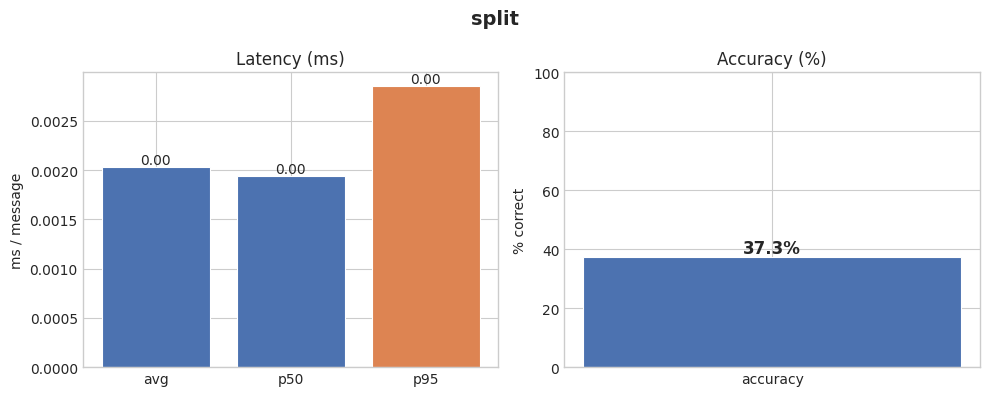

In [413]:
plot_single_result(result1, CONFIG)

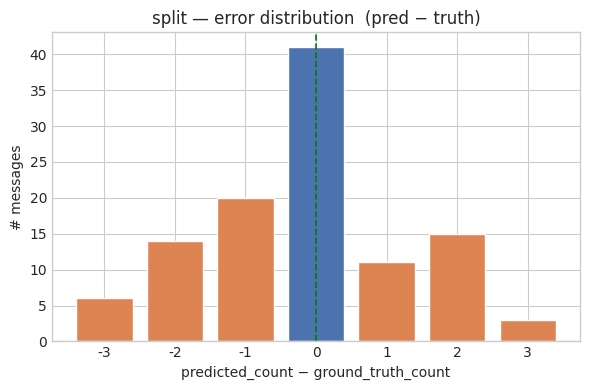

In [414]:
plot_error_distribution(result1, CONFIG)

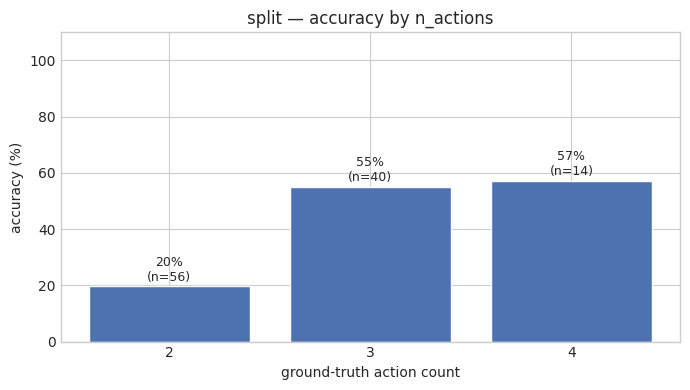

In [415]:
plot_per_class(result1, CONFIG)

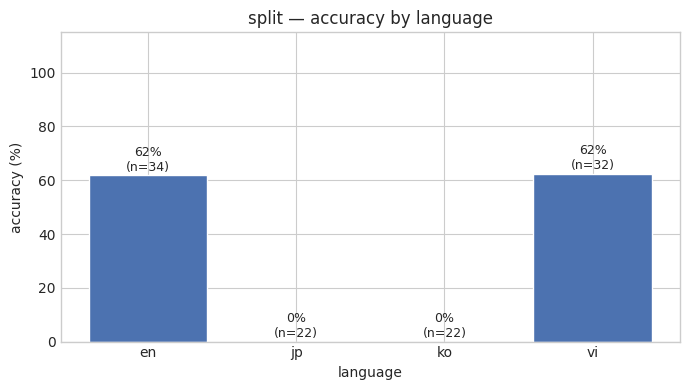

In [416]:
plot_per_lang(result1, CONFIG)

## 13 · Run: Method 2 — semantic

In [417]:
result2 = run_benchmark(
    func         = METHODS[1]["func"],
    name         = METHODS[1]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : semantic
  Accuracy : 37.3%  (41/110)
  Avg time : 7.87 ms/msg
  p50      : 10.43 ms  |  p95 : 16.67 ms
    [en] 61.8%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 62.5%  (n=32)
────────────────────────────────────────────────


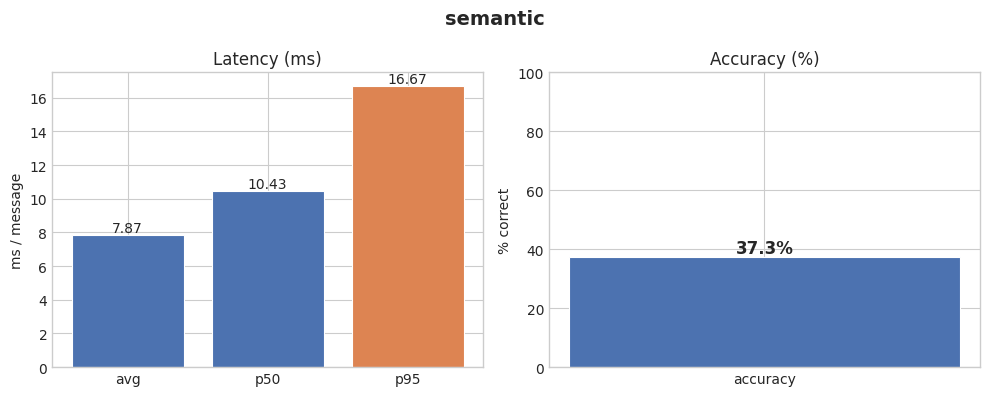

In [418]:
plot_single_result(result2, CONFIG)

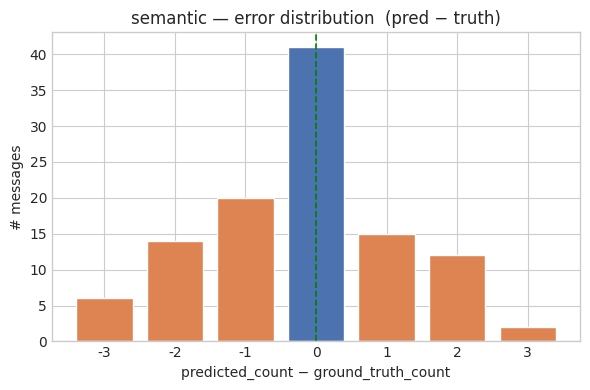

In [419]:
plot_error_distribution(result2, CONFIG)

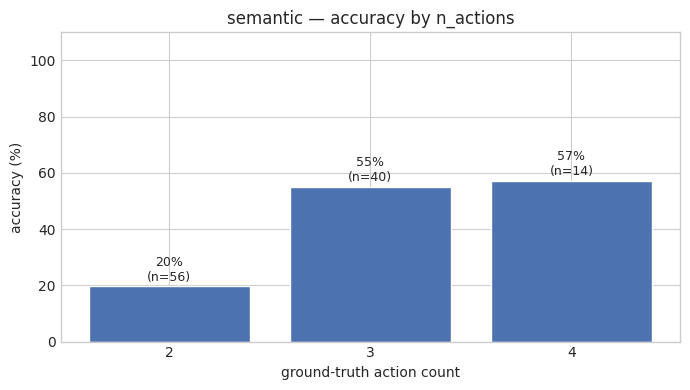

In [420]:
plot_per_class(result2, CONFIG)

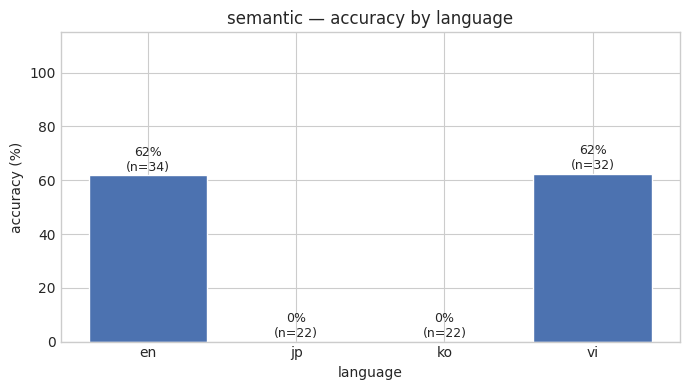

In [421]:
plot_per_lang(result2, CONFIG)

## 14 · Run: Method 3 — semantic + merge

In [422]:
result3 = run_benchmark(
    func         = METHODS[2]["func"],
    name         = METHODS[2]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : semantic+merge
  Accuracy : 9.1%  (10/110)
  Avg time : 8.09 ms/msg
  p50      : 10.39 ms  |  p95 : 18.36 ms
    [en] 14.7%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 0.0%  (n=22)
    [vi] 15.6%  (n=32)
────────────────────────────────────────────────


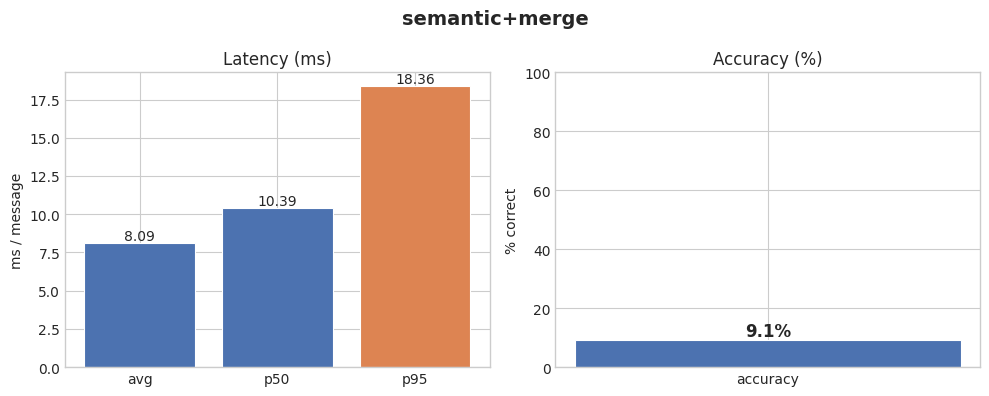

In [423]:
plot_single_result(result3, CONFIG)

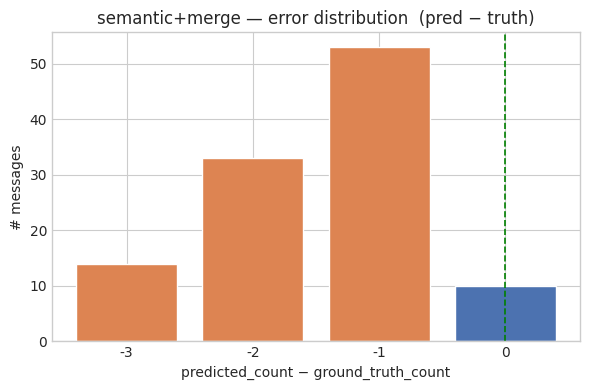

In [424]:
plot_error_distribution(result3, CONFIG)

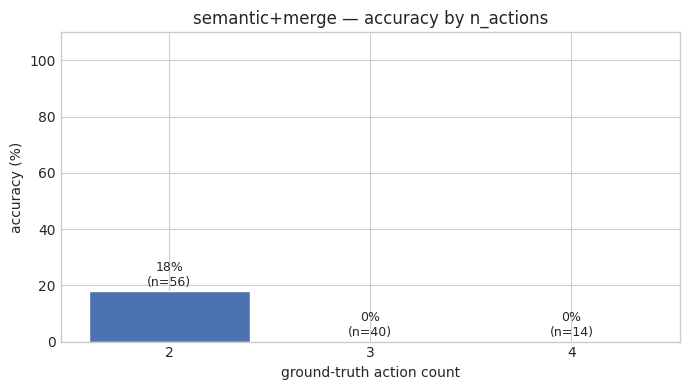

In [425]:
plot_per_class(result3, CONFIG)

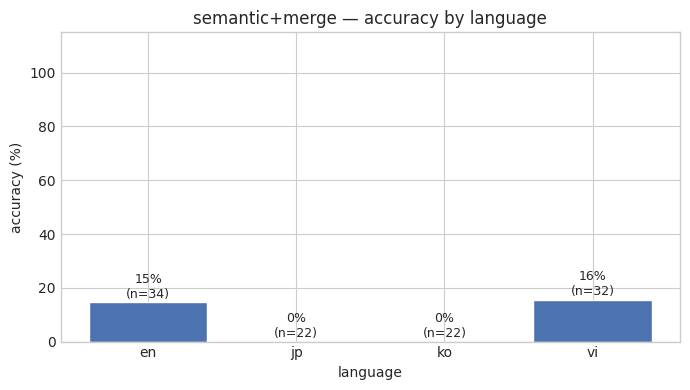

In [426]:
plot_per_lang(result3, CONFIG)

## 15 · Run: Method 4 — verb-guard-merge

In [427]:
result4 = run_benchmark(
    func         = METHODS[3]["func"],
    name         = METHODS[3]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : verb-guard-merge
  Accuracy : 57.3%  (63/110)
  Avg time : 0.01 ms/msg
  p50      : 0.01 ms  |  p95 : 0.01 ms
    [en] 91.2%  (n=34)
    [jp] 0.0%  (n=22)
    [ko] 18.2%  (n=22)
    [vi] 87.5%  (n=32)
────────────────────────────────────────────────


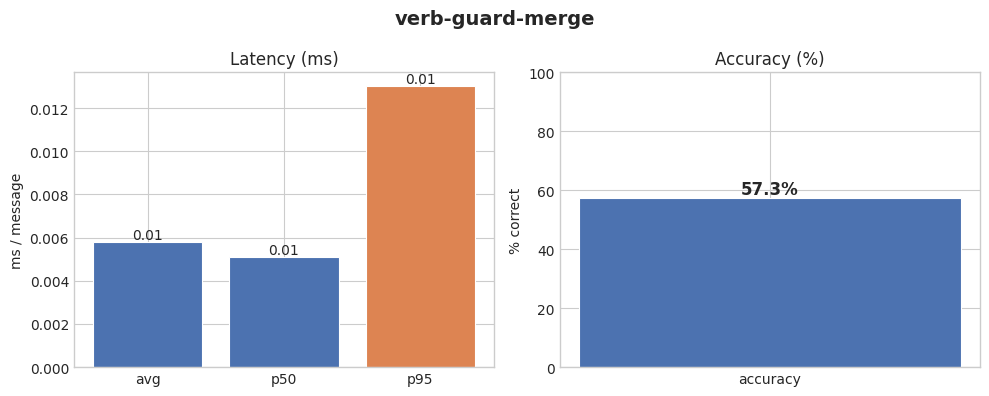

In [428]:
plot_single_result(result4, CONFIG)

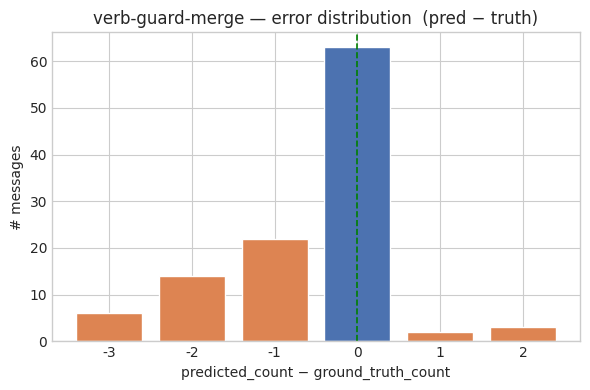

In [429]:
plot_error_distribution(result4, CONFIG)

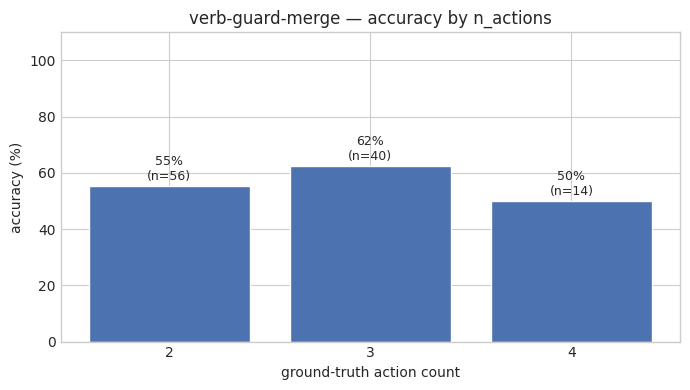

In [430]:
plot_per_class(result4, CONFIG)

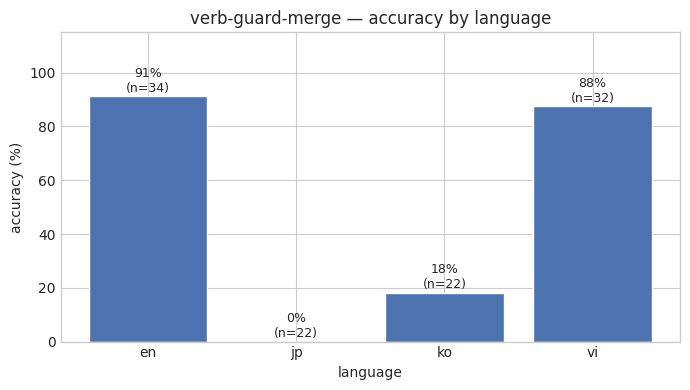

In [431]:
plot_per_lang(result4, CONFIG)

## 16 · Run: Method 5 — cjk-verb-guard

In [432]:
result5 = run_benchmark(
    func         = METHODS[4]["func"],
    name         = METHODS[4]["name"],
    cfg          = CONFIG,
    messages     = messages,
    ground_truth = no_actions,
    langs        = languages,
)

────────────────────────────────────────────────
  Method   : cjk-verb-guard
  Accuracy : 61.8%  (68/110)
  Avg time : 0.03 ms/msg
  p50      : 0.01 ms  |  p95 : 0.02 ms
    [en] 91.2%  (n=34)
    [jp] 22.7%  (n=22)
    [ko] 18.2%  (n=22)
    [vi] 87.5%  (n=32)
────────────────────────────────────────────────


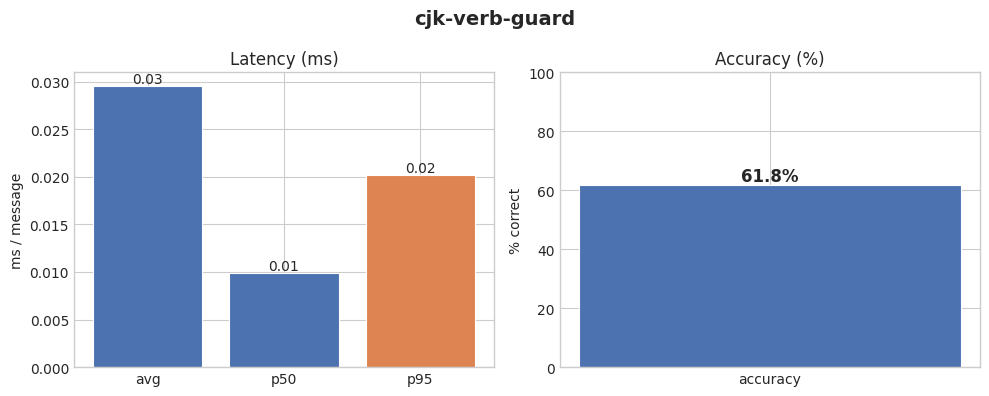

In [433]:
plot_single_result(result5, CONFIG)

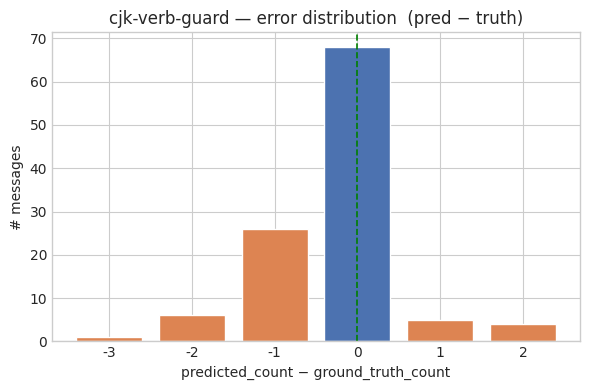

In [434]:
plot_error_distribution(result5, CONFIG)

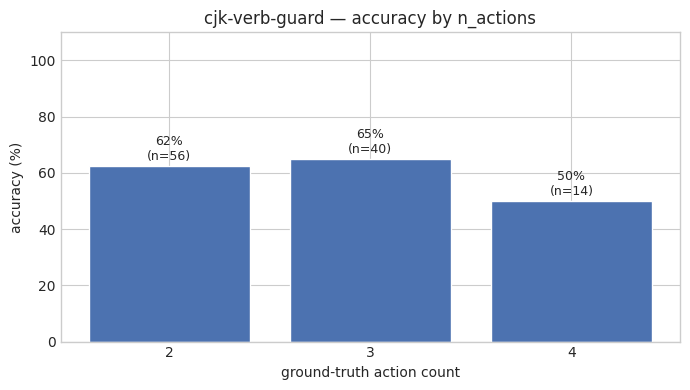

In [435]:
plot_per_class(result5, CONFIG)

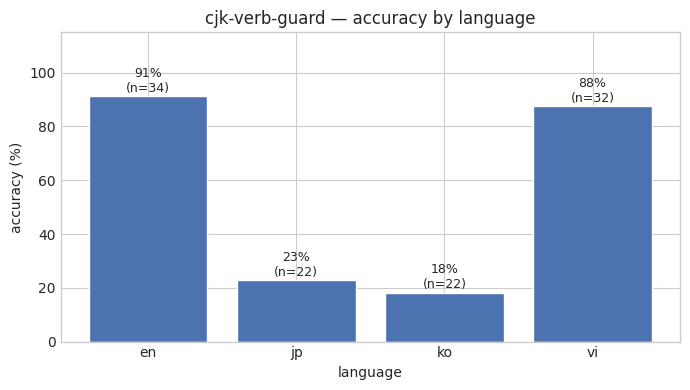

In [436]:
plot_per_lang(result5, CONFIG)

## 17 · Final Comparison

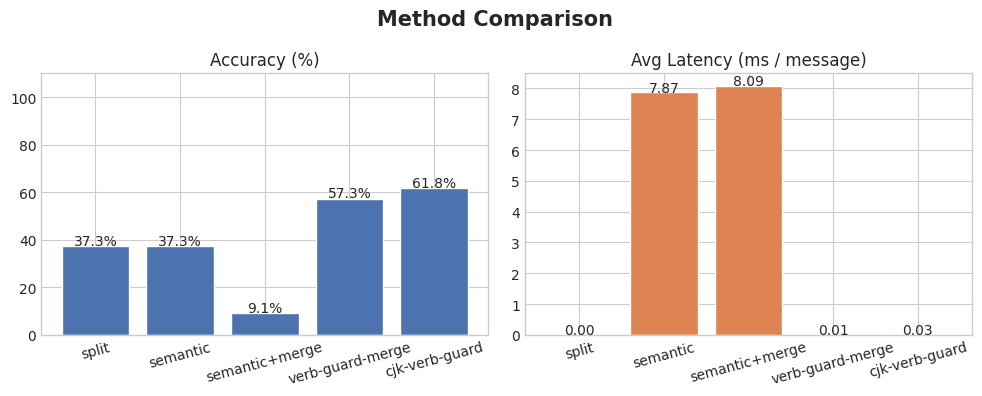

In [437]:
all_results = [result1, result2, result3, result4, result5]

plot_comparison(all_results, CONFIG)

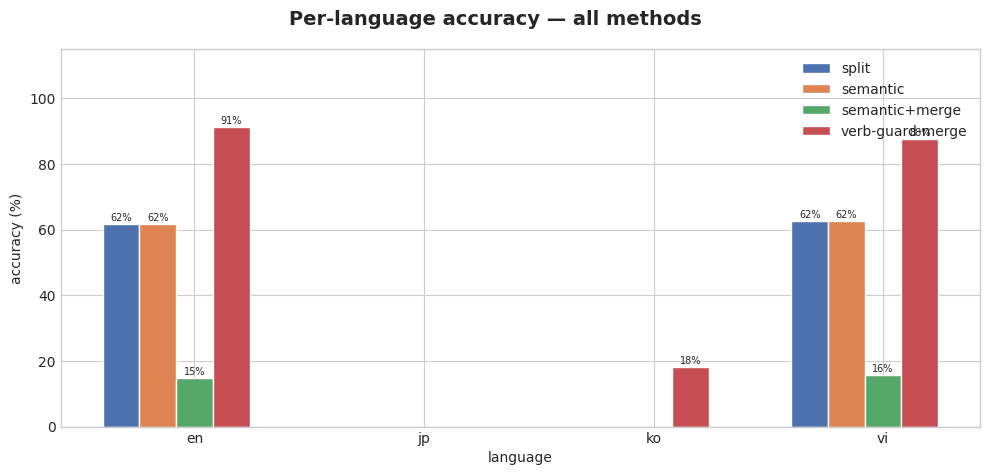

In [438]:
plot_lang_comparison(all_results, CONFIG)

In [439]:
# Summary table
summary_df = pd.DataFrame([
    {
        "method":      r["name"],
        "accuracy_%":  round(r["accuracy"] * 100, 2),
        "avg_ms":      round(r["avg_time_ms"], 3),
        "p50_ms":      round(r["p50_ms"], 3),
        "p95_ms":      round(r["p95_ms"], 3),
    }
    for r in all_results
])
summary_df

,method,accuracy_%,avg_ms,p50_ms,p95_ms
0,split,37.27,0.002,0.002,0.003
1,semantic,37.27,7.872,10.434,16.670
2,semantic+merge,9.09,8.087,10.386,18.359
3,verb-guard-merge,57.27,0.006,0.005,0.013
4,cjk-verb-guard,61.82,0.030,0.010,0.020


## 18 · Sample-level Inspection

Useful during development — inspect individual predictions for any method.

In [440]:
def inspect_samples(
    result:       dict,
    ground_truth: list[int],
    messages:     list[str],
    n:            int = 10,
    only_errors:  bool = True,
) -> pd.DataFrame:
    """
    Return a DataFrame of individual predictions.

    Parameters
    ----------
    result       : output dict from run_benchmark
    ground_truth : list of expected action counts
    messages     : original raw utterances
    n            : max rows to return
    only_errors  : if True, return only rows where prediction was wrong
    """
    rows = []
    for msg, pred, gt in zip(messages, result["results"], ground_truth):
        correct = len(pred) == gt
        if only_errors and correct:
            continue
        rows.append({
            "message":    msg,
            "predicted":  pred,
            "n_pred":     len(pred),
            "n_gt":       gt,
            "correct":    correct,
        })
        if len(rows) >= n:
            break
    return pd.DataFrame(rows)

In [454]:
# Example: show first 10 errors from method 2
inspect_samples(result4, no_actions, messages, n=10, only_errors=True)

,message,predicted,n_pred,n_gt,correct
0,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,[마이클 잭슨에 대해 말해주고 그의 노래 틀어줘],1,2,False
1,ドアを開けて音楽を流して東京まで案内して,[ドアを開けて音楽を流して東京まで案内して],1,2,False
2,트렁크 열고 음악 틀어줘,[트렁크 열고 음악 틀어줘],1,2,False
3,마이클 잭슨에 대해 말해주고 그의 노래 틀어줘,[마이클 잭슨에 대해 말해주고 그의 노래 틀어줘],1,2,False
4,문 열고 음악 틀고 서울로 안내해,[문 열고 음악 틀고 서울로 안내해],1,3,False
5,메시에 대해 말해주고 그의 영상 틀고 집으로 안내해,[메시에 대해 말해주고 그의 영상 틀고 집으로 안내해],1,3,False
6,에어컨 켜고 음악 틀고 농담 말해줘,[에어컨 켜고 음악 틀고 농담 말해줘],1,3,False
7,문 열고 음악 틀고 전화 걸고 길 안내해,[문 열고 음악 틀고 전화 걸고 길 안내해],1,4,False
8,ドアを開けて音楽を流して,[ドアを開けて音楽を流して],1,2,False
9,トランクとドアとサンルーフを開けて音楽を流して,[トランクとドアとサンルーフを開けて音楽を流して],1,2,False


---
## 19 · Per-Language Accuracy — All Methods

Cross-tabulation: rows = language, columns = method.
Makes it easy to spot which language is hardest for each method,
and whether one method consistently dominates on a specific language.

In [442]:
def build_lang_table(all_results: list[dict]) -> pd.DataFrame:
    """
    Build a wide-format summary table:
      index   = language code
      columns = one accuracy column per method  (e.g. "split_%")
      extra   = "n_total" (sample count, same across methods)

    Parameters
    ----------
    all_results : list of result dicts from run_benchmark (with per_lang set)

    Returns
    -------
    DataFrame sorted by language code.
    """
    frames = []
    for r in all_results:
        if r["per_lang"] is None:
            continue
        pl = r["per_lang"].copy()
        pl = pl.rename(columns={"accuracy": r["name"] + "_%"})
        pl[r["name"] + "_%"] = (pl[r["name"] + "_%"] * 100).round(2)
        frames.append(pl.set_index("lang")[[r["name"] + "_%", "total"]])

    if not frames:
        print("No per_lang data available.")
        return pd.DataFrame()

    # Merge all methods on lang index, keep one "total" column
    merged = frames[0]
    for f in frames[1:]:
        merged = merged.join(f.drop(columns=["total"], errors="ignore"), how="outer")

    merged = merged.rename(columns={"total": "n_total"})
    merged.index.name = "lang"
    return merged.sort_index()

In [443]:
lang_table = build_lang_table(all_results)
lang_table

,split_%,n_total,semantic_%,semantic+merge_%,verb-guard-merge_%,cjk-verb-guard_%
lang,,,,,,
en,61.76,34,61.76,14.71,91.18,91.18
jp,0.00,22,0.00,0.00,0.00,22.73
ko,0.00,22,0.00,0.00,18.18,18.18
vi,62.50,32,62.50,15.62,87.50,87.50


---
## 20 · Experiment A — `min_words_merge` sweep (methods 3 & 4)

We vary `min_words_merge` from **2 → 6** (step 1) while keeping every
other config value fixed.  A fragment is merged into its predecessor only
when it has **fewer** words than this threshold.

**Hypothesis**: a larger threshold aggressively merges more short
fragments, which may reduce over-splitting but risks under-splitting
when a short fragment is a genuine intent.

Methods under test:
- `method3_semantic_merge`  — semantic split then merge-short
- `method4_verb_guard_merge` — split then verb-guarded merge

In [445]:
SWEEP_MIN_WORDS = list(range(2, 7))   # [2, 3, 4, 5, 6]

exp_a_results: dict[str, list[dict]] = {
    "semantic+merge":    [],
    "verb-guard-merge":  [],
}

for mw in SWEEP_MIN_WORDS:
    sweep_cfg = {**CONFIG, "min_words_merge": mw}

    for func, label in [
        (method3_semantic_merge,   "semantic+merge"),
        (method4_verb_guard_merge, "verb-guard-merge"),
    ]:
        r = run_benchmark(
            func         = func,
            name         = f"{label}  min_words={mw}",
            cfg          = sweep_cfg,
            messages     = messages,
            ground_truth = no_actions,
            verbose      = True,
        )
        r["min_words_merge"] = mw        # tag so we can plot it
        exp_a_results[label].append(r)

────────────────────────────────────────────────
  Method   : semantic+merge  min_words=2
  Accuracy : 47.3%  (52/110)
  Avg time : 8.63 ms/msg
  p50      : 11.49 ms  |  p95 : 17.86 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : verb-guard-merge  min_words=2
  Accuracy : 47.3%  (52/110)
  Avg time : 0.01 ms/msg
  p50      : 0.00 ms  |  p95 : 0.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic+merge  min_words=3
  Accuracy : 23.6%  (26/110)
  Avg time : 7.84 ms/msg
  p50      : 10.30 ms  |  p95 : 17.51 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : verb-guard-merge  min_words=3
  Accuracy : 54.5%  (59/110)
  Avg time : 0.01 ms/msg
  p50      : 0.00 ms  |  p95 : 0.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : se

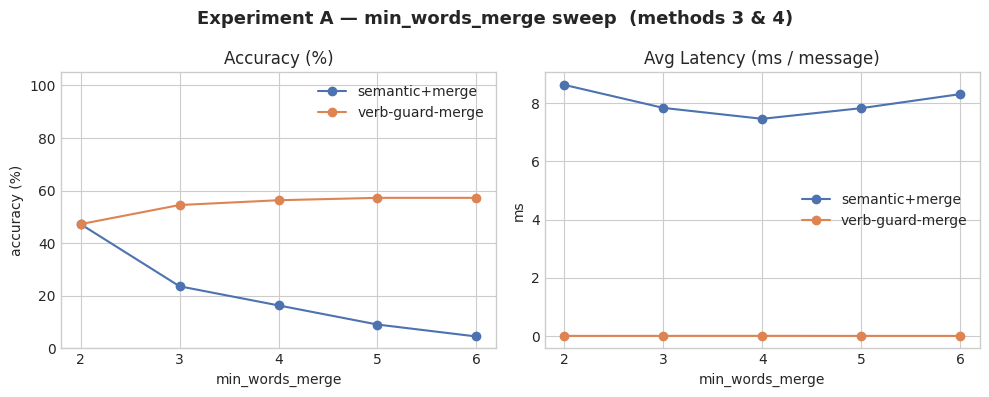

In [446]:
# ── Plot Experiment A ──────────────────────────────────────────────────────
def plot_exp_a(
    exp_results: dict[str, list[dict]],
    sweep_values: list[int],
    cfg: dict,
) -> None:
    """
    Line chart: accuracy and avg latency vs min_words_merge,
    one line per method.
    """
    _apply_style(cfg)
    fig, axes = plt.subplots(1, 2, figsize=(cfg["fig_width"], cfg["fig_height"]))
    fig.suptitle(
        "Experiment A — min_words_merge sweep  (methods 3 & 4)",
        fontsize=13, fontweight="bold",
    )

    colors = [cfg["bar_color"], cfg["accent_color"]]

    for (label, results), color in zip(exp_results.items(), colors):
        accs = [r["accuracy"] * 100 for r in results]
        lats = [r["avg_time_ms"]    for r in results]

        axes[0].plot(sweep_values, accs, marker="o", label=label, color=color)
        axes[1].plot(sweep_values, lats, marker="o", label=label, color=color)

    axes[0].set_title("Accuracy (%)")
    axes[0].set_xlabel("min_words_merge")
    axes[0].set_ylabel("accuracy (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_xticks(sweep_values)
    axes[0].legend()

    axes[1].set_title("Avg Latency (ms / message)")
    axes[1].set_xlabel("min_words_merge")
    axes[1].set_ylabel("ms")
    axes[1].set_xticks(sweep_values)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_exp_a(exp_a_results, SWEEP_MIN_WORDS, CONFIG)

In [447]:
# ── Summary table — Experiment A ──────────────────────────────────────────
exp_a_rows = []
for label, results in exp_a_results.items():
    for r in results:
        exp_a_rows.append({
            "method":          label,
            "min_words_merge": r["min_words_merge"],
            "accuracy_%":      round(r["accuracy"] * 100, 2),
            "avg_ms":          round(r["avg_time_ms"], 3),
            "p50_ms":          round(r["p50_ms"], 3),
            "p95_ms":          round(r["p95_ms"], 3),
        })

exp_a_df = (
    pd.DataFrame(exp_a_rows)
    .sort_values(["method", "min_words_merge"])
    .reset_index(drop=True)
)
exp_a_df

,method,min_words_merge,accuracy_%,avg_ms,p50_ms,p95_ms
0,semantic+merge,2,47.27,8.629,11.486,17.865
1,semantic+merge,3,23.64,7.838,10.304,17.507
2,semantic+merge,4,16.36,7.463,10.198,15.084
3,semantic+merge,5,9.09,7.829,9.927,17.296
4,semantic+merge,6,4.55,8.311,10.528,17.631
5,verb-guard-merge,2,47.27,0.005,0.004,0.012
6,verb-guard-merge,3,54.55,0.006,0.005,0.012
7,verb-guard-merge,4,56.36,0.007,0.005,0.012
8,verb-guard-merge,5,57.27,0.005,0.004,0.012
9,verb-guard-merge,6,57.27,0.005,0.004,0.011


In [448]:
# Best min_words_merge per method (by accuracy)
exp_a_df.loc[
    exp_a_df.groupby("method")["accuracy_%"].idxmax()
][["method", "min_words_merge", "accuracy_%", "avg_ms"]]

,method,min_words_merge,accuracy_%,avg_ms
0,semantic+merge,2,47.27,8.629
8,verb-guard-merge,5,57.27,0.005


---
## 21 · Experiment B — `similarity_threshold` sweep (methods 2 & 3)

We vary `similarity_threshold` across **[0.7, 0.8, 0.9]** while keeping
every other config value fixed.

A higher threshold means two fragments must be *more* similar for them to
be merged — i.e. the method becomes more conservative and splits more.

Methods under test (those that use embeddings):
- `method2_semantic`       — semantic split + pronoun resolution
- `method3_semantic_merge` — method 2 + short-fragment merging

In [449]:
SWEEP_SIM_THRESHOLDS = [0.7, 0.8, 0.9]

exp_b_results: dict[str, list[dict]] = {
    "semantic":       [],
    "semantic+merge": [],
}

for thresh in SWEEP_SIM_THRESHOLDS:
    sweep_cfg = {**CONFIG, "similarity_threshold": thresh}

    for func, label in [
        (method2_semantic,       "semantic"),
        (method3_semantic_merge, "semantic+merge"),
    ]:
        r = run_benchmark(
            func         = func,
            name         = f"{label}  sim={thresh}",
            cfg          = sweep_cfg,
            messages     = messages,
            ground_truth = no_actions,
            verbose      = True,
        )
        r["similarity_threshold"] = thresh   # tag for plotting
        exp_b_results[label].append(r)

────────────────────────────────────────────────
  Method   : semantic  sim=0.7
  Accuracy : 37.3%  (41/110)
  Avg time : 7.86 ms/msg
  p50      : 10.40 ms  |  p95 : 17.51 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic+merge  sim=0.7
  Accuracy : 9.1%  (10/110)
  Avg time : 7.73 ms/msg
  p50      : 10.32 ms  |  p95 : 18.01 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic  sim=0.8
  Accuracy : 37.3%  (41/110)
  Avg time : 7.86 ms/msg
  p50      : 10.75 ms  |  p95 : 16.47 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic+merge  sim=0.8
  Accuracy : 9.1%  (10/110)
  Avg time : 8.45 ms/msg
  p50      : 10.41 ms  |  p95 : 17.95 ms
────────────────────────────────────────────────
────────────────────────────────────────────────
  Method   : semantic  sim=0.9
  Accuracy : 3

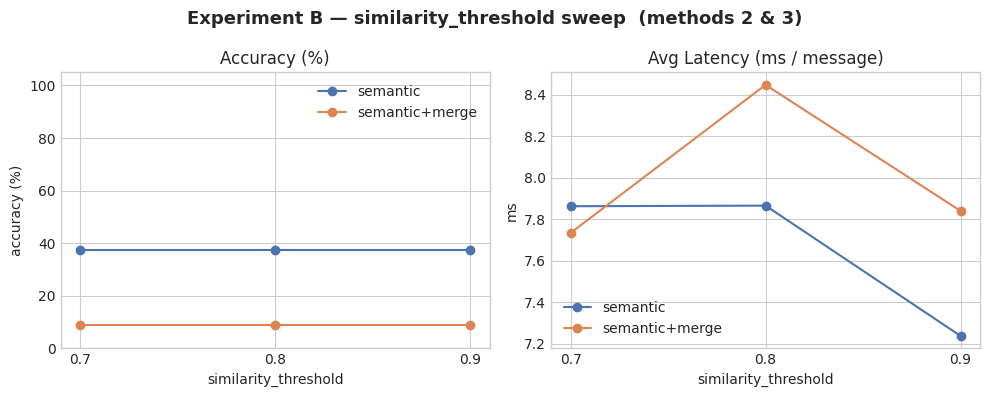

In [450]:
# ── Plot Experiment B ──────────────────────────────────────────────────────
def plot_exp_b(
    exp_results:   dict[str, list[dict]],
    sweep_values:  list[float],
    cfg:           dict,
) -> None:
    """
    Line chart: accuracy and avg latency vs similarity_threshold,
    one line per method.
    """
    _apply_style(cfg)
    fig, axes = plt.subplots(1, 2, figsize=(cfg["fig_width"], cfg["fig_height"]))
    fig.suptitle(
        "Experiment B — similarity_threshold sweep  (methods 2 & 3)",
        fontsize=13, fontweight="bold",
    )

    colors = [cfg["bar_color"], cfg["accent_color"]]

    for (label, results), color in zip(exp_results.items(), colors):
        accs = [r["accuracy"] * 100 for r in results]
        lats = [r["avg_time_ms"]    for r in results]

        axes[0].plot(sweep_values, accs, marker="o", label=label, color=color)
        axes[1].plot(sweep_values, lats, marker="o", label=label, color=color)

    axes[0].set_title("Accuracy (%)")
    axes[0].set_xlabel("similarity_threshold")
    axes[0].set_ylabel("accuracy (%)")
    axes[0].set_ylim(0, 105)
    axes[0].set_xticks(sweep_values)
    axes[0].legend()

    axes[1].set_title("Avg Latency (ms / message)")
    axes[1].set_xlabel("similarity_threshold")
    axes[1].set_ylabel("ms")
    axes[1].set_xticks(sweep_values)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_exp_b(exp_b_results, SWEEP_SIM_THRESHOLDS, CONFIG)

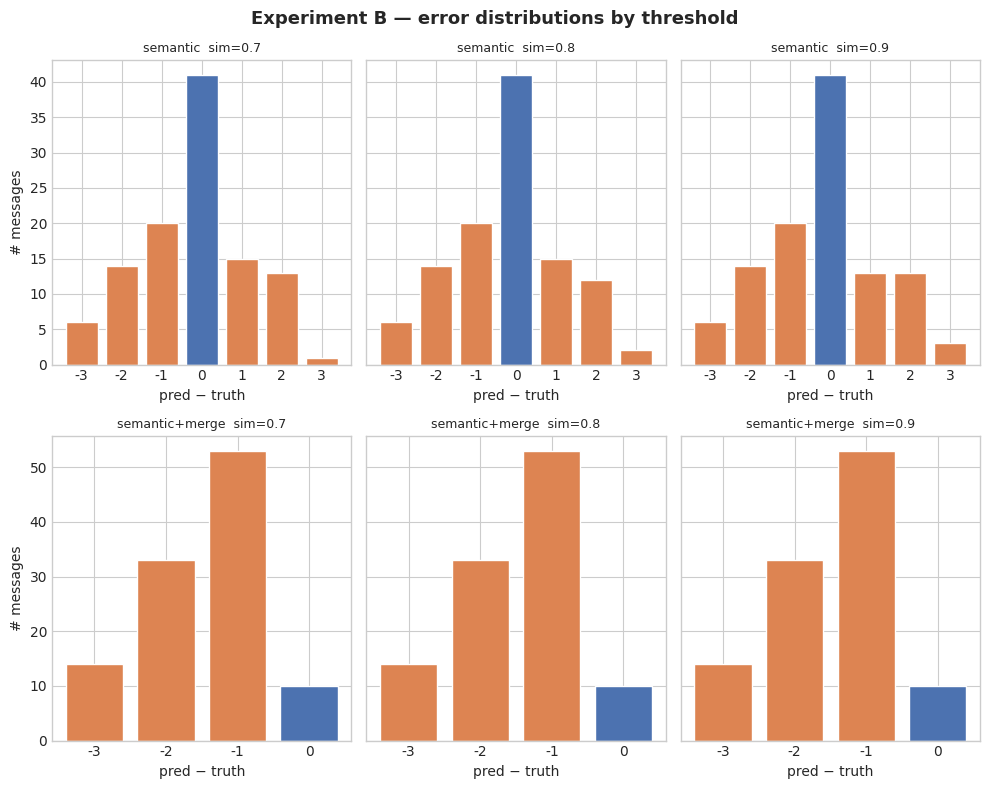

In [451]:
# ── Error distribution per threshold — Experiment B ───────────────────────
# Shows whether a higher threshold shifts the model toward over- or under-splitting
def plot_exp_b_errors(
    exp_results:  dict[str, list[dict]],
    cfg:          dict,
) -> None:
    """
    For each method, one row of subplots — one per threshold value.
    Each subplot is the error distribution (pred − truth).
    """
    _apply_style(cfg)
    methods = list(exp_results.keys())
    thresholds = [r["similarity_threshold"] for r in next(iter(exp_results.values()))]
    n_thresh = len(thresholds)

    fig, axes = plt.subplots(
        len(methods), n_thresh,
        figsize=(cfg["fig_width"], cfg["fig_height"] * len(methods)),
        sharey="row",
    )
    # Ensure axes is always 2-D
    if len(methods) == 1:
        axes = [axes]

    for row_idx, label in enumerate(methods):
        for col_idx, r in enumerate(exp_results[label]):
            ax  = axes[row_idx][col_idx]
            err = r["errors"]
            colors = [
                cfg["bar_color"] if idx == 0 else cfg["accent_color"]
                for idx in err.index
            ]
            ax.bar(err.index.astype(str), err.values, color=colors, edgecolor="white")
            ax.set_title(
                f"{label}  sim={r['similarity_threshold']}",
                fontsize=9,
            )
            ax.set_xlabel("pred − truth")
            if col_idx == 0:
                ax.set_ylabel("# messages")

    fig.suptitle(
        "Experiment B — error distributions by threshold",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

plot_exp_b_errors(exp_b_results, CONFIG)

In [452]:
# ── Summary table — Experiment B ──────────────────────────────────────────
exp_b_rows = []
for label, results in exp_b_results.items():
    for r in results:
        exp_b_rows.append({
            "method":               label,
            "similarity_threshold": r["similarity_threshold"],
            "accuracy_%":           round(r["accuracy"] * 100, 2),
            "avg_ms":               round(r["avg_time_ms"], 3),
            "p50_ms":               round(r["p50_ms"], 3),
            "p95_ms":               round(r["p95_ms"], 3),
        })

exp_b_df = (
    pd.DataFrame(exp_b_rows)
    .sort_values(["method", "similarity_threshold"])
    .reset_index(drop=True)
)
exp_b_df

,method,similarity_threshold,accuracy_%,avg_ms,p50_ms,p95_ms
0,semantic,0.7,37.27,7.862,10.401,17.509
1,semantic,0.8,37.27,7.865,10.749,16.470
2,semantic,0.9,37.27,7.237,10.010,14.580
3,semantic+merge,0.7,9.09,7.733,10.322,18.014
4,semantic+merge,0.8,9.09,8.446,10.414,17.951
5,semantic+merge,0.9,9.09,7.839,10.170,17.541


In [453]:
# Best similarity_threshold per method (by accuracy)
exp_b_df.loc[
    exp_b_df.groupby("method")["accuracy_%"].idxmax()
][["method", "similarity_threshold", "accuracy_%", "avg_ms"]]

,method,similarity_threshold,accuracy_%,avg_ms
0,semantic,0.7,37.27,7.862
3,semantic+merge,0.7,9.09,7.733
